# Optimizers & Learning Rate Schedules

Optimization is the process of finding model parameters $\theta$ that minimize the loss $\mathcal{L}(\theta)$.

## 1. Gradient Descent Variants

### 1.1 Batch Gradient Descent
Uses the **entire dataset** to compute the gradient:
$$\theta \leftarrow \theta - \eta \nabla_\theta \mathcal{L}(\theta)$$
- Stable updates, guaranteed convergence on convex problems
- **Very slow** for large datasets

### 1.2 Stochastic Gradient Descent (SGD)
Uses **one sample** per update:
$$\theta \leftarrow \theta - \eta \nabla_\theta \mathcal{L}(\theta; x^{(i)}, y^{(i)})$$
- Noisy updates, can escape local minima
- **High variance** in updates

### 1.3 Mini-Batch Gradient Descent
Uses a **batch** of $B$ samples:
$$\theta \leftarrow \theta - \eta \nabla_\theta \mathcal{L}(\theta; X^{(i:i+B)}, y^{(i:i+B)})$$
- Balance between stability and speed. **Standard in practice.**

## 2. SGD with Momentum

Accumulates a velocity vector to accelerate optimization:
$$v_t = \beta v_{t-1} + \eta \nabla_\theta \mathcal{L}$$
$$\theta \leftarrow \theta - v_t$$

Typical $\beta = 0.9$. Momentum accelerates in consistent gradient directions and dampens oscillations.

## 3. Nesterov Accelerated Gradient (NAG)

Looks ahead before computing gradient:
$$v_t = \beta v_{t-1} + \eta \nabla_\theta \mathcal{L}(\theta - \beta v_{t-1})$$
$$\theta \leftarrow \theta - v_t$$

Converges faster than standard momentum.

## 4. AdaGrad

Adapts learning rate per parameter larger updates for infrequent features:
$$G_t = G_{t-1} + g_t^2$$
$$\theta \leftarrow \theta - \frac{\eta}{\sqrt{G_t + \epsilon}} g_t$$

**Problem**: $G_t$ grows monotonically → learning rate shrinks to zero.

## 5. RMSprop

Fixes AdaGrad's diminishing LR with an **exponential moving average**:
$$E[g^2]_t = \gamma E[g^2]_{t-1} + (1-\gamma) g_t^2$$
$$\theta \leftarrow \theta - \frac{\eta}{\sqrt{E[g^2]_t + \epsilon}} g_t$$

Typical: $\gamma = 0.9$, $\epsilon = 10^{-8}$.

## 6. Adam (Adaptive Moment Estimation)

Combines momentum + RMSprop. Tracks first and second moments:

$$m_t = \beta_1 m_{t-1} + (1-\beta_1) g_t \quad \text{(first moment)}$$
$$v_t = \beta_2 v_{t-1} + (1-\beta_2) g_t^2 \quad \text{(second moment)}$$

**Bias correction** (important at early timesteps when $m_t, v_t$ are near 0):
$$\hat{m}_t = \frac{m_t}{1 - \beta_1^t}, \quad \hat{v}_t = \frac{v_t}{1 - \beta_2^t}$$

**Update:**
$$\theta \leftarrow \theta - \frac{\eta}{\sqrt{\hat{v}_t} + \epsilon} \hat{m}_t$$

Defaults: $\beta_1=0.9$, $\beta_2=0.999$, $\epsilon=10^{-8}$, $\eta=10^{-3}$.

## 7. AdamW

Decouples weight decay from gradient update (fixes L2 regularization in Adam):
$$\theta \leftarrow \theta - \frac{\eta}{\sqrt{\hat{v}_t} + \epsilon} \hat{m}_t - \eta \lambda \theta$$

Weight decay applied **directly** to parameters, not through gradient. **Preferred over Adam** in most cases.

## 8. RAdam (Rectified Adam)

Fixes Adam's variance issue in early training by computing a rectified step size.

## 9. LAMB (Layer-wise Adaptive Moments)

Scales Adam updates by layer-wise trust ratio enables **very large batch training** (used in BERT pre-training):
$$\theta_l \leftarrow \theta_l - \eta \frac{||\theta_l||}{||\hat{m}_l / (\sqrt{\hat{v}_l}+\epsilon) + \lambda\theta_l||} \left(\frac{\hat{m}_l}{\sqrt{\hat{v}_l}+\epsilon} + \lambda\theta_l\right)$$

## 10. Lion Optimizer

Discovered via program search (Chen et al., 2023). Uses only **sign of gradient**:
$$c_t = \beta_1 m_{t-1} + (1-\beta_1) g_t$$
$$\theta \leftarrow \theta - \eta (\text{sign}(c_t) + \lambda \theta)$$
$$m_t = \beta_2 m_{t-1} + (1-\beta_2) g_t$$
More memory efficient than Adam (stores one moment instead of two).

## 11. Learning Rate Schedules

### Step Decay
$$\eta_t = \eta_0 \cdot \gamma^{\lfloor t/s \rfloor}$$

### Exponential Decay
$$\eta_t = \eta_0 \cdot e^{-\lambda t}$$

### Cosine Annealing
$$\eta_t = \eta_{min} + \frac{1}{2}(\eta_{max} - \eta_{min})\left(1 + \cos\frac{\pi t}{T}\right)$$

### Warmup + Cosine (used in Transformers)
Linear warmup for $t_{warmup}$ steps, then cosine decay.

### Cyclic Learning Rate
Oscillates LR between a min and max value (Smith, 2017).

## 12. Gradient Clipping

Prevents exploding gradients by scaling the gradient norm:
$$\text{if } ||g|| > \text{threshold}: \quad g \leftarrow g \cdot \frac{\text{threshold}}{||g||}$$

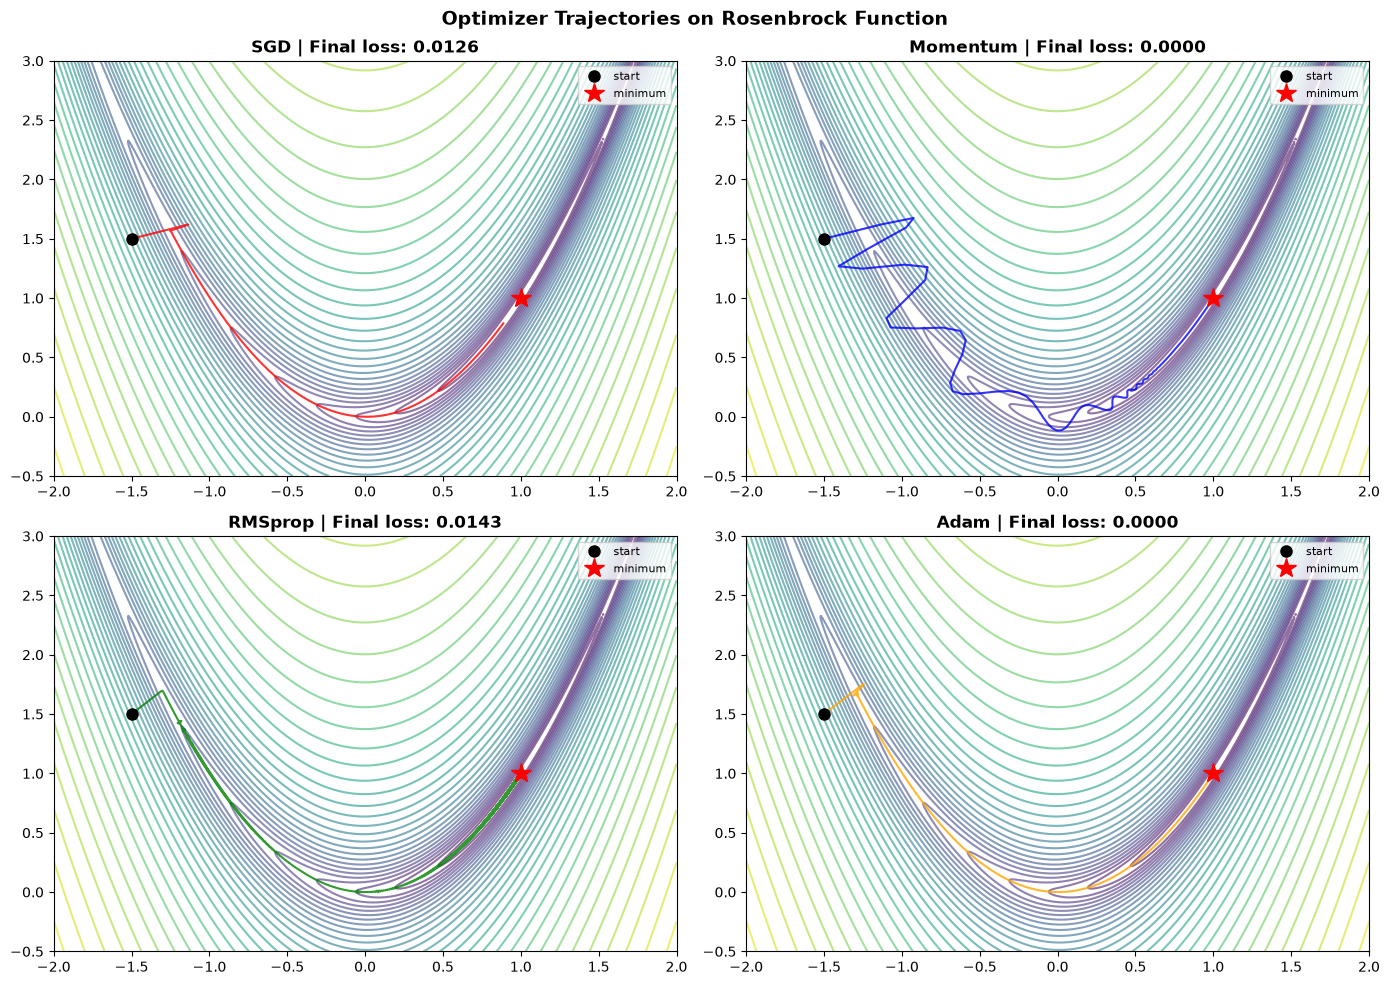

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Optimizers from Scratch on a 2D Rosenbrock function
# ============================================================

def rosenbrock(x, y, a=1, b=100):
    return (a - x)**2 + b*(y - x**2)**2

def rosenbrock_grad(x, y, a=1, b=100):
    dx = -2*(a-x) - 4*b*x*(y - x**2)
    dy = 2*b*(y - x**2)
    return np.array([dx, dy])

class SGD_optimizer:
    def __init__(self, lr=0.001):
        self.lr = lr
    def step(self, params, grads):
        return params - self.lr * grads

class Momentum_optimizer:
    def __init__(self, lr=0.001, beta=0.9):
        self.lr, self.beta, self.v = lr, beta, None
    def step(self, params, grads):
        if self.v is None: self.v = np.zeros_like(grads)
        self.v = self.beta * self.v + self.lr * grads
        return params - self.v

class Adam_optimizer:
    def __init__(self, lr=0.01, b1=0.9, b2=0.999, eps=1e-8):
        self.lr,self.b1,self.b2,self.eps = lr,b1,b2,eps
        self.m = self.v = None
        self.t = 0
    def step(self, params, grads):
        if self.m is None:
            self.m = np.zeros_like(grads)
            self.v = np.zeros_like(grads)
        self.t += 1
        self.m = self.b1*self.m + (1-self.b1)*grads
        self.v = self.b2*self.v + (1-self.b2)*grads**2
        m_hat = self.m / (1 - self.b1**self.t)
        v_hat = self.v / (1 - self.b2**self.t)
        return params - self.lr * m_hat / (np.sqrt(v_hat) + self.eps)

class RMSprop_optimizer:
    def __init__(self, lr=0.01, gamma=0.9, eps=1e-8):
        self.lr,self.gamma,self.eps,self.E = lr,gamma,eps,None
    def step(self, params, grads):
        if self.E is None: self.E = np.zeros_like(grads)
        self.E = self.gamma*self.E + (1-self.gamma)*grads**2
        return params - self.lr * grads / (np.sqrt(self.E) + self.eps)

def run_optimizer(opt, n_steps=5000, start=(-1.5, 1.5)):
    path = [np.array(start, dtype=float)]
    p = np.array(start, dtype=float)
    for _ in range(n_steps):
        g = rosenbrock_grad(*p)
        p = opt.step(p, g)
        path.append(p.copy())
    return np.array(path)

optimizers = [
    ('SGD',      SGD_optimizer(lr=0.0008)),
    ('Momentum', Momentum_optimizer(lr=0.0008, beta=0.9)),
    ('RMSprop',  RMSprop_optimizer(lr=0.008)),
    ('Adam',     Adam_optimizer(lr=0.02)),
]

x_grid = np.linspace(-2, 2, 400)
y_grid = np.linspace(-0.5, 3, 400)
X_g, Y_g = np.meshgrid(x_grid, y_grid)
Z_g = rosenbrock(X_g, Y_g)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors = ['red','blue','green','orange']
for ax, (name, opt), color in zip(axes.flat, optimizers, colors):
    path = run_optimizer(opt)
    ax.contour(X_g, Y_g, np.log(Z_g+1), levels=30, cmap='viridis', alpha=0.6)
    ax.plot(path[:,0], path[:,1], color=color, lw=1.5, alpha=0.8)
    ax.plot(*path[0], 'ko', ms=8, label='start')
    ax.plot(1, 1, 'r*', ms=15, label='minimum')
    ax.set_title(f'{name} | Final loss: {rosenbrock(*path[-1]):.4f}', fontweight='bold')
    ax.set_xlim(-2, 2); ax.set_ylim(-0.5, 3)
    ax.legend(fontsize=8)

plt.suptitle('Optimizer Trajectories on Rosenbrock Function', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

/tmp/ipykernel_57907/3068452510.py:35: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  sched.step()


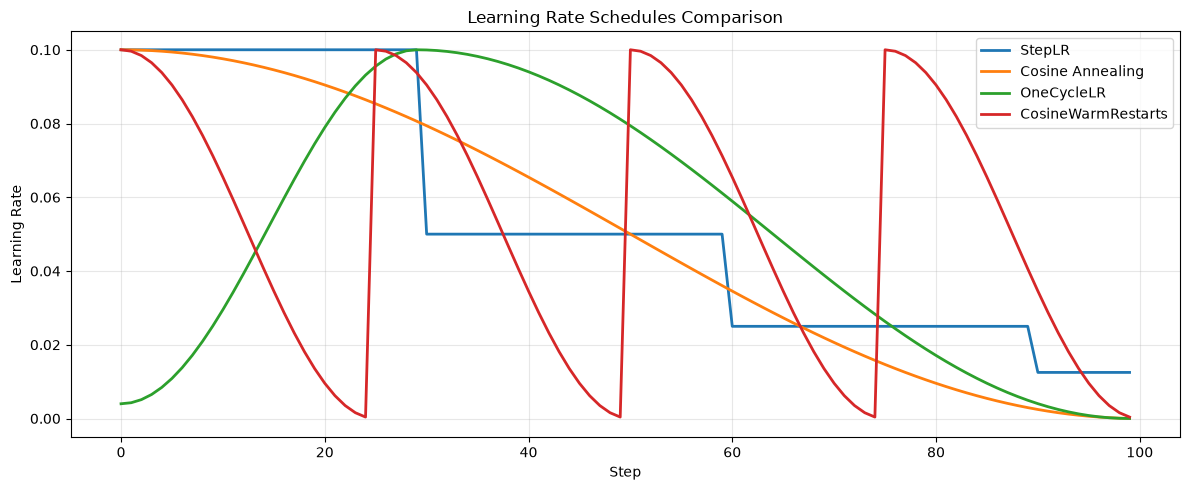


--- Gradient Clipping ---
Gradient norm before clipping: 2311.7935
Gradient norm after  clipping: 1.0000


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import (StepLR, ExponentialLR, CosineAnnealingLR,
                                       CyclicLR, OneCycleLR, CosineAnnealingWarmRestarts)
import matplotlib.pyplot as plt

# --- Compare PyTorch optimizers ---
def make_model(): return nn.Sequential(nn.Linear(2,64), nn.ReLU(), nn.Linear(64,1))

# Learning rate schedule visualization
dummy_model = make_model()
schedules = {
    'StepLR(step=30,gamma=0.5)': StepLR(optim.SGD(dummy_model.parameters(),lr=0.1), step_size=30, gamma=0.5),
}
dummy_model2 = make_model()
sched2 = CosineAnnealingLR(optim.Adam(dummy_model2.parameters(), lr=0.1), T_max=100)
dummy_model3 = make_model()
sched3 = OneCycleLR(optim.Adam(dummy_model3.parameters(), lr=0.001), max_lr=0.1,
                    total_steps=100, pct_start=0.3)
dummy_model4 = make_model()
sched4 = CosineAnnealingWarmRestarts(optim.Adam(dummy_model4.parameters(), lr=0.1), T_0=25)

fig, ax = plt.subplots(figsize=(12, 5))
all_schedules = [
    (schedules['StepLR(step=30,gamma=0.5)'], 'StepLR'),
    (sched2, 'Cosine Annealing'),
    (sched3, 'OneCycleLR'),
    (sched4, 'CosineWarmRestarts'),
]
for sched, name in all_schedules:
    lrs = []
    for _ in range(100):
        lrs.append(sched.get_last_lr()[0] if hasattr(sched, 'get_last_lr') and sched.get_last_lr() else sched.optimizer.param_groups[0]['lr'])
        sched.step()
    ax.plot(lrs, label=name, lw=2)

ax.set_xlabel('Step'); ax.set_ylabel('Learning Rate')
ax.set_title('Learning Rate Schedules Comparison')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# --- Gradient Clipping demo ---
print('\n--- Gradient Clipping ---')
model = make_model()
criterion = nn.MSELoss()
opt = optim.SGD(model.parameters(), lr=0.01)

X = torch.randn(32, 2) * 100  # large inputs -> large gradients
y = torch.randn(32, 1)

loss = criterion(model(X), y)
loss.backward()

total_norm_before = 0
for p in model.parameters():
    total_norm_before += p.grad.norm().item()**2
total_norm_before = total_norm_before**0.5

torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

total_norm_after = 0
for p in model.parameters():
    total_norm_after += p.grad.norm().item()**2
total_norm_after = total_norm_after**0.5

print(f'Gradient norm before clipping: {total_norm_before:.4f}')
print(f'Gradient norm after  clipping: {total_norm_after:.4f}')

## Additional Learning Resources

### Key Papers
- **Adam** (Kingma & Ba, 2014): https://arxiv.org/abs/1412.6980
- **AdamW** (Loshchilov & Hutter, 2019): https://arxiv.org/abs/1711.05101
- **LAMB** (You et al., 2019): https://arxiv.org/abs/1904.00962
- **RAdam** (Liu et al., 2019): https://arxiv.org/abs/1908.03265
- **Lion** (Chen et al., 2023): https://arxiv.org/abs/2302.06675
- **Cyclical LR** (Smith, 2017): https://arxiv.org/abs/1506.01186
- **1Cycle Policy** (Smith & Topin, 2019): https://arxiv.org/abs/1708.07120
- **Warmup + Cosine** (Transformer paper): https://arxiv.org/abs/1706.03762

### Blogs & Tutorials
- **An Overview of Gradient Descent Variants** Sebastian Ruder: https://ruder.io/optimizing-gradient-descent/
- **Why Momentum Really Works** Distill.pub: https://distill.pub/2017/momentum/
- **PyTorch Optimizer Docs**: https://pytorch.org/docs/stable/optim.html
- **CS231n Optimization Notes**: https://cs231n.github.io/optimization-1/

### Courses
- **Deep Learning Specialization** Andrew Ng (Coursera): https://www.coursera.org/specializations/deep-learning
- **Fast.ai Practical Deep Learning**: https://course.fast.ai/